# PyTorch Basics

In this notebook, we will learn the PyTorch tools needed for simple deep learning.

You will practice:
- creating tensors
- changing tensor shape
- using basic tensor math
- loading image data
- batching data with a DataLoader
- building a tiny neural network
- running a forward pass
- computing loss
- training a model for a few steps

These ideas will prepare you for image classification tasks later.

## What is PyTorch?

PyTorch is a library for deep learning.

It gives us:
- tensors, which are like NumPy arrays
- automatic differentiation
- neural network layers
- training utilities

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## Tensors

A tensor is the main data type in PyTorch.

You can think of it as a NumPy-like array that works well with neural networks.

In [ ]:
# Create a 1D tensor.

x = torch.tensor([1.0, 2.0, 3.0])
print(x)
print("shape:", x.shape)
print("dtype:", x.dtype)

In [ ]:
# Create a 2D tensor.

A = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]
])

print(A)
print("shape:", A.shape)

## Basic tensor operations

Many tensor operations look similar to NumPy.

In [ ]:
# Element-wise addition and multiplication.

print("A + A:\n", A + A)
print("A * A:\n", A * A)

In [ ]:
# Scalar operations.

print("A * 2:\n", A * 2)

## Reshape and flatten

Neural networks often expect data in a specific shape.
PyTorch makes reshaping easy.

In [ ]:
# Reshape a tensor.

B = torch.arange(12)
print("B:", B)
print("B reshaped:\n", B.reshape(3, 4))

In [ ]:
# Flatten a tensor back into 1D.

C = torch.arange(12).reshape(3, 4)
print("Original shape:", C.shape)
print("Flattened shape:", C.flatten().shape)

## Indexing tensors

Tensor indexing works like NumPy indexing.

In [ ]:
# Access rows, columns, and single values.

print(C[0])
print(C[:, 1])
print(C[1, 2])

## Gradients

PyTorch can compute gradients automatically.
This is what makes training neural networks possible.

In [ ]:
# Create a tensor that tracks gradients.

w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)

y = w * x
print("y:", y)

In [ ]:
# Backpropagate through the computation graph.

y.backward()
print("gradient of w:", w.grad)

## Simple neural network layer

A linear layer is one of the simplest building blocks in deep learning.
It learns a weighted combination of input values.

In [ ]:
# A tiny linear layer with 4 inputs and 2 outputs.

layer = nn.Linear(4, 2)
print(layer)

In [ ]:
# Create one fake input example with 4 features.

x = torch.randn(1, 4)
output = layer(x)

print("input shape:", x.shape)
print("output shape:", output.shape)
print(output)

## Activation functions

Activation functions add nonlinearity to a model.
A common one is ReLU.

In [ ]:
relu = nn.ReLU()

values = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print(relu(values))

## Loss functions

A loss function measures how far the model is from the target.

During training, we try to reduce the loss.

In [ ]:
# Example for a classification task with 2 classes.

loss_fn = nn.CrossEntropyLoss()

logits = torch.tensor([[2.0, 0.5],
                       [0.1, 1.7]])

labels = torch.tensor([0, 1])

loss = loss_fn(logits, labels)
print("loss:", loss.item())

## Optimizers

An optimizer updates model parameters using gradients.

In [ ]:
model = nn.Linear(4, 2)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

## Tiny training step

Below is the standard pattern:
1. zero gradients
2. forward pass
3. compute loss
4. backward pass
5. update parameters

In [ ]:
x = torch.randn(5, 4)
y = torch.tensor([0, 1, 0, 1, 1])

logits = model(x)
loss = loss_fn(logits, y)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("loss:", loss.item())

## Dataset and DataLoader

A Dataset stores data.

A DataLoader makes batches automatically.
This is very useful when training on many images.

In [ ]:
class ToyDataset(Dataset):
    def __init__(self):
        self.x = torch.randn(20, 4)
        self.y = torch.randint(0, 2, (20,))

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [ ]:
dataset = ToyDataset()
loader = DataLoader(dataset, batch_size=4, shuffle=True)

for batch_x, batch_y in loader:
    print("batch_x shape:", batch_x.shape)
    print("batch_y shape:", batch_y.shape)
    break

# Sales Prediction Example (Inspired by [ML Mastery](https://machinelearningmastery.com/training-a-linear-regression-model-in-pytorch/))

We will cover the following workflow:

1. Generate synthetic data
2. Visualize data
3. Train linear model
4. Observe limitations
5. Compare with nonlinear model

## Generate Synthetic Data

- Creates input feature `X`
- Defines the true function: linear trend + sinusoidal pattern ```y = 5x + 20 + sin(x)```
- Adds random noise to simulate real-world data
- Observe the plot:
    + The dashed line = true function
    + Scatter points = noisy observations

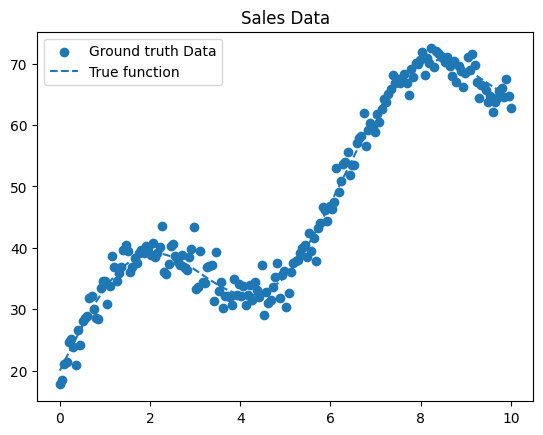

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

# clean function + noise
X = torch.linspace(0, 10, 200).view(-1, 1)

# Linear + nonlinear component
true_func = 5 * X + 20 + 10 * torch.sin(X)

# Add noise
Y = true_func + 2 * torch.randn(X.size())

# Plot
plt.scatter(X.numpy(), Y.numpy(), label="Ground truth Data")
plt.plot(X.numpy(), true_func.numpy(), linestyle="--", label="True function")
plt.legend()
plt.title("Sales Data")
plt.show()

## Train Linear Regression Model

- Defines a simple linear model: `y = wx + b`
- Uses Mean Squared Error (MSE) as loss
- Trains using stochastic gradient descent

In [9]:
# Model: y = wx + b
model = torch.nn.Linear(1, 1)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

losses = []

for epoch in range(150):
    y_pred = model(X)
    loss = loss_fn(y_pred, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

print("Final linear loss:", loss.item())

Final linear loss: 77.66150665283203


## Visualize Linear Model Predictions

- Plots:
  - actual data (scatter)
  - linear model predictions (line)
  - true function (dashed)
- Insights:
    - The prediction is a **straight line**
    - It misses the **wave pattern**

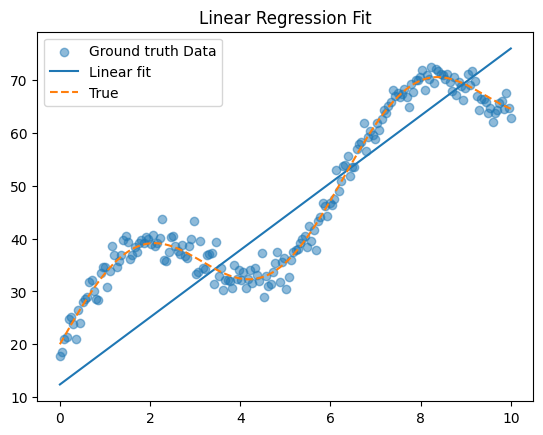

In [10]:
with torch.no_grad():
    y_pred = model(X)

plt.scatter(X.numpy(), Y.numpy(), alpha=0.5, label="Ground truth Data")
plt.plot(X.numpy(), y_pred.numpy(), label="Linear fit")
plt.plot(X.numpy(), true_func.numpy(), linestyle="--", label="True")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()

## Plot Linear Training Loss

- Shows how loss changes over epochs
- Loss decreases and converges after a few first epochs
- Even after convergence, loss is still relatively high
- Indicates the model **cannot fully fit the data**

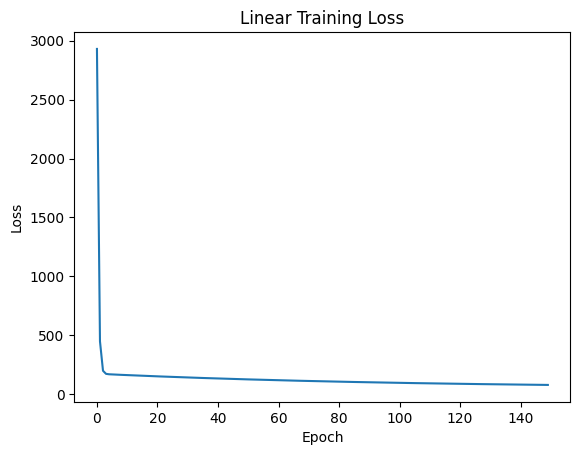

In [11]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Linear Training Loss")
plt.show()

## Train Nonlinear Neural Network

- Defines a multi-layer neural network with ReLU activations
- Allows learning of nonlinear relationships
- Loss decreases further than linear model
- Model has more flexibility to fit complex patterns

In [12]:
model_nn = torch.nn.Sequential(
    torch.nn.Linear(1, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 1)
)

optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.01)

losses_nn = []

for epoch in range(200):
    y_pred_nn = model_nn(X)
    loss = loss_fn(y_pred_nn, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_nn.append(loss.item())

print("Final nonlinear loss:", loss.item())

Final nonlinear loss: 32.743221282958984


## Compare Linear vs Nonlinear Predictions

- Plots:
  - data points
  - linear model predictions
  - nonlinear model predictions
  - true function
- Insight:
  - Nonlinear model approximates the true function better
- Next step: 
  - The prediction is still not satisfactory. Improve it by normalizing both X and Y, and replacing ReLU with Tanh to produce smoother predictions.

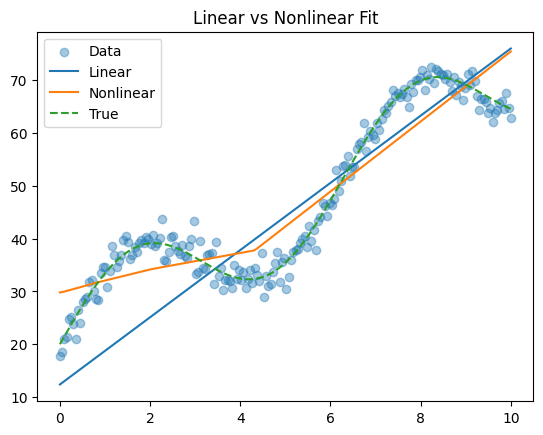

In [14]:
with torch.no_grad():
    y_pred_nn = model_nn(X)

plt.scatter(X.numpy(), Y.numpy(), alpha=0.4, label="Data")
plt.plot(X.numpy(), y_pred.numpy(), label="Linear")
plt.plot(X.numpy(), y_pred_nn.numpy(), label="Nonlinear")
plt.plot(X.numpy(), true_func.numpy(), linestyle="--", label="True")

plt.legend()
plt.title("Linear vs Nonlinear Fit")
plt.show()

## Plot Non-Linear Training Loss

- Shows how loss changes over epochs
- Loss decreases and converges after around 50 epochs
- Even after convergence, loss is still high, but much lower than that of the linear model

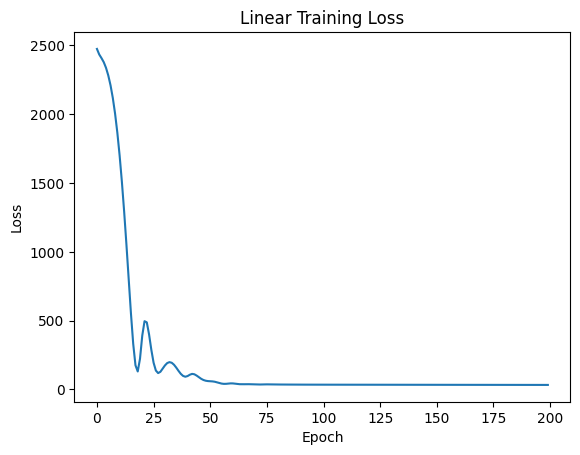

In [15]:
plt.plot(losses_nn)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Linear Training Loss")
plt.show()